# Colitis Ulcerative
## Sick vs Healthy prediction

In [135]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder

In [136]:
# Loading the data
otu = pd.read_csv(
    "C:\\Users\\bruge\\OneDrive - University of Copenhagen\\2. år\\4. Metagenomic Analysis of Microbiome\\group-project-group-5\\project\\data\\D003093_Colitis,_Ulcerative\\genus\\otu_table.xls",
    sep="\t"
)

metadata = pd.read_csv(
    "C:\\Users\\bruge\\OneDrive - University of Copenhagen\\2. år\\4. Metagenomic Analysis of Microbiome\\group-project-group-5\\project\\data\\D003093_Colitis,_Ulcerative\\genus\\sample_data.xls",
    sep="\t"
)

In [137]:
# Preparing the data
otu = otu.set_index(otu.columns[0])

# Transposing
X = otu.T

In [138]:
# print column names of metadata
print(metadata.columns)

print(metadata['Disease.name'].value_counts())
print(metadata['Disease.MESH.ID'].value_counts())

#D006262 = raske
#D003093 = UC

Index(['#SampleID', 'Project.ID', 'Experiment.type', 'Nr..reads.sequenced',
       'Country', 'Sex', 'Host.age', 'BMI', 'Recent.antibiotics.use',
       'Disease.MESH.ID', 'Disease.name', 'QC.status'],
      dtype='object')
Disease.name
1    1066
Name: count, dtype: int64
Disease.MESH.ID
D006262    615
D003093    451
Name: count, dtype: int64


In [139]:
metadata.head()

,#SampleID,Project.ID,Experiment.type,Nr..reads.sequenced,Country,Sex,Host.age,BMI,Recent.antibiotics.use,Disease.MESH.ID,Disease.name,QC.status
0,ERR209057,PRJEB1220,Metagenomics,7764468.0,Denmark,NaN,NaN,NaN,NaN,D006262,1,1
1,ERR209058,PRJEB1220,Metagenomics,4465624.0,Denmark,NaN,NaN,NaN,NaN,D006262,1,1
2,ERR209059,PRJEB1220,Metagenomics,9317812.0,Denmark,NaN,NaN,NaN,NaN,D006262,1,1
3,ERR209060,PRJEB1220,Metagenomics,9644824.0,Denmark,NaN,NaN,NaN,NaN,D006262,1,1
4,ERR209061,PRJEB1220,Metagenomics,9615221.0,Denmark,NaN,NaN,NaN,NaN,D006262,1,1


In [140]:
# count unique counts of Disease.MESH.ID in denmark, usa, spain (Country column)
print("Count of sick and healthy in Denmark:")
print(metadata[metadata['Country'] == 'Denmark']['Disease.MESH.ID'].value_counts())

print("Count of sick and healthy in USA:")
print(metadata[metadata['Country'] == 'United States of America']['Disease.MESH.ID'].value_counts())

print("Count of sick and healthy in Spain:")
print(metadata[metadata['Country'] == 'Spain']['Disease.MESH.ID'].value_counts())

Count of sick and healthy in Denmark:
Disease.MESH.ID
D006262    444
Name: count, dtype: int64
Count of sick and healthy in USA:
Disease.MESH.ID
D003093    138
D006262     55
Name: count, dtype: int64
Count of sick and healthy in Spain:
Disease.MESH.ID
D003093    223
D006262    116
Name: count, dtype: int64


In [141]:
metadata = metadata.dropna(subset=["Country"])

metadata = metadata[metadata["Country"] != "Denmark"]

print(metadata["Country"].value_counts())
print(metadata.shape)

Country
Spain                       339
United States of America    193
Name: count, dtype: int64
(532, 12)


In [142]:
# Preparing column names
metadata = metadata.reset_index(drop=True)

target_col = "Disease.MESH.ID"

metadata = metadata.set_index("#SampleID")

# Match metadata to OTU samples
common_samples = metadata.index.intersection(X.index)
metadata = metadata.loc[common_samples]
X = X.loc[common_samples]

y = metadata[target_col]

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)


In [143]:
# Data split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [144]:
print(X_train.shape, y_train.shape)

(425, 78) (425,)


In [145]:
# Prediction
y_pred = model.predict(X_test)

In [146]:
# Evaluate
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.93      0.88        73
           1       0.80      0.59      0.68        34

    accuracy                           0.82       107
   macro avg       0.81      0.76      0.78       107
weighted avg       0.82      0.82      0.81       107



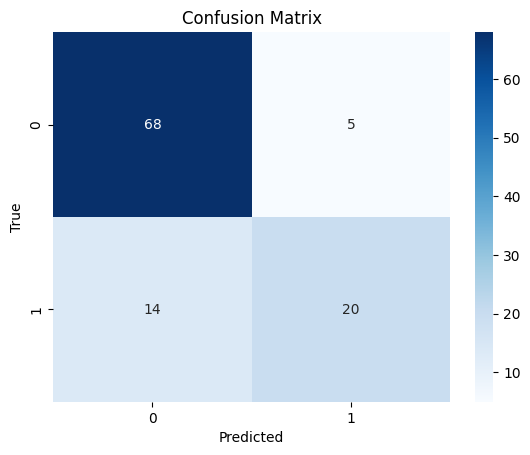

In [147]:
# confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
#from sklearn.preprocessing import OneHotEncoder
#import pandas as pd

#country_encoded = pd.get_dummies(metadata["Country"])

#X = pd.concat([otu, country_encoded], axis=1)

In [151]:
model.feature_importances_

array([0.00000000e+00, 1.29982978e-04, 0.00000000e+00, 0.00000000e+00,
       8.47697507e-04, 3.39130234e-04, 1.55386689e-02, 0.00000000e+00,
       1.85858708e-03, 0.00000000e+00, 9.36806006e-04, 0.00000000e+00,
       0.00000000e+00, 5.95653266e-03, 7.30107063e-02, 1.46189403e-02,
       1.58566394e-03, 2.09773968e-02, 4.50466503e-02, 2.90708435e-03,
       8.73108647e-03, 2.96581767e-03, 0.00000000e+00, 6.28576994e-04,
       6.12390667e-02, 6.80858446e-03, 3.61715104e-06, 7.29157387e-05,
       1.29915681e-04, 0.00000000e+00, 2.12589594e-02, 6.39913216e-03,
       0.00000000e+00, 4.00950532e-02, 6.85704675e-02, 1.34581078e-02,
       5.50311927e-04, 9.07145749e-03, 0.00000000e+00, 7.29178398e-03,
       3.39818800e-02, 8.34241187e-03, 3.79524754e-02, 9.22063295e-03,
       0.00000000e+00, 3.68178589e-03, 1.34830068e-04, 0.00000000e+00,
       3.22716536e-03, 1.09762843e-02, 0.00000000e+00, 2.11241098e-04,
       4.43634563e-03, 8.10119394e-04, 1.07757301e-02, 0.00000000e+00,
      